In [1]:
import matplotlib.pyplot as plt
import numpy as np; np.random.seed(337)

from matplotlib import animation

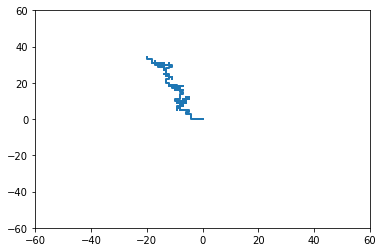

In [4]:
# First set up the figure, the axis, and the plot element 
fig = plt.figure()
ax = plt.axes(xlim=(-60, 60), ylim=(-60, 60))
line, = ax.plot([], [], lw=2)

# initialization function: plot the background of each frame
def init():
    line.set_data([], [])
    return line,

start_position = np.array([0, 0]) 
x_history = [0]
y_history = [0]

# animation function.  This is called sequentially
def animate(i):
    global start_position, x_history, y_history
    
    if np.random.uniform(0., 1.) > 0.75:
        end_position = start_position + np.array([1, 0]) 
    elif np.random.uniform(0., 1.) > 0.50:
        end_position = start_position + np.array([-1, 0]) 
    elif np.random.uniform(0., 1.) > 0.25:
        end_position = start_position + np.array([0, 1]) 
    else:
        end_position = start_position + np.array([0, -1]) 
        
    x_history.append(end_position[0])
    y_history.append(end_position[1])
        
    line.set_data(x_history, y_history)
    
    start_position = end_position
        
    return line,

# call the animator.  
# We've chosen a 200 frame animation with a 20ms delay between frames.
# blit=True means only re-draw the parts that have changed.
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=200, interval=20, blit=True)

# save the animation as an mp4.  
# This requires ffmpeg or mencoder to be installed.

# https://www.videosurveillance.com/tech/frame-rate.asp
# 30 fps means the camera captured 30 frames in a single second of video

# The extra_args ensure that the x264 codec is used, so that
# the video can be embedded in html5.  
# You may need to adjust this for your system: for more information, see
# http://matplotlib.sourceforge.net/api/animation_api.html
anim.save('img/2d_simple_random_walk.mp4', fps=30, extra_args=['-vcodec', 'libx264'])